# Nonlinear Regression

## Overview

Questions
- How can I perform statistically robust non-linear regression in a jupyter notebook?
- How can I prepare accurate and attractive plots of my regression results that include the best-fit line?

Objectives
- Import data from a file
- Create a function based on the equation to be fitted
- Generate a best-fit curve with parameters and statistical descriptors
- Create plots of the data


## Data-fitting

In an earlier workshop we used the `linregress` function from the `scipy.stats` library to perform linear regression.  This is an excellent method for least squares regression to fit a straight line to the data.  However, not all data fits a straight line relationship - and indeed the enzyme kinetics data we have now generated fits a shae know as a "rectangular hyperbola".  Python contains tools that enable us to fit data to an equation that we have defined, with two or more parameters.  These tools are ideal for fitting a curve to our Michaelis Menten equation, which describes the shape that our data (should!) show.

In this workshop, we will use some familiar tools:  importing data from a .csv file into a pandas dataframe, and plotting the results using the `matplot.pyplot` library.  We will asloe **create a function** based on the Michaelis Menten equation.  The exciting part is learning how to fit the data to the function using `curve_fit` from `scipy.optimize`

Here are the steps in our process:

1. Import the libraries and functions that you need including `curve fit` from `scipy.optimize`
2. Set up a pandas dataframe from the .csv file containing your enzyme kinetics data - I will use a file called MM_data.csv
3. Create your independent and dependent variables for curve fitting
4. Create a function for the equation you want to fit.  The function should acccept as inputs the independent variables and all the parameters to be fitted
5. Use the function `curve_fit` to fit your data
6. Extract the fit parameters from the output of `curve_fit`
7. Use your function to calculate y-values using your fit model to see how well your model fits your experimental data
8. Graph your experimental data and data generated using the best-fit equation

In [1]:
# Import the libraries and functions that you need: os, numpy (pseudonym np), pandas (pseudonym pd), matplotlib.pyplot (pseudonym plt), and curve_fit from the scipy.optimize library

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



## The Michaelis Menten equation

The Michaelis-Menten equation describes the relationship between substreate concetration and the initial velocity of enzyme-catalysed reactions.  We will use the simplest version of the equation, based on initial reaction velocities with a single substrate.

In our equation there are two parameters an indepedntent variable and a dependent variable:

- Parameter 1 - Vmax - the maximum initial velocity that can be achieved when all enzyme molcules are working as hard as they can
- Parameter 2 - Km - The MIchaelis constant, which is the concentration that delivers half the maximal rate; and which tells us about the affinity of our enzyme for the substrate
- Independent variable - SubConc - the concentration of the substrate [S] (on our Michaelis-Menten plot, this forms the X-axis, which is where you would expect to find an independent variable)
- Dependent variable - Vo - The initial velocity of the enzyme catalysed reaction (on our Michaelis-Menten plot, this forms the Y-axis)

$$
\
V_o = \dfrac{V_{max} * [S]}{K_m + [S]}
\
$$


In [2]:
# Set up a pandas dataframe from the MM_data.csv file (or your file containing data from your lab experiment).

# 1. Create a filehandle

datafile = os.path.join('data', 'MM_data.csv')

# 2. Import the data

MM_df = pd.read_csv(datafile)

# Inspect the data to make sure you have substrate concentrations and initial velocities

MM_df.head()

,Lactate (mM),Rates
0,150.00,131.237942
1,75.00,137.990354
2,37.50,118.745981
3,18.75,59.662379
4,9.38,1.736334


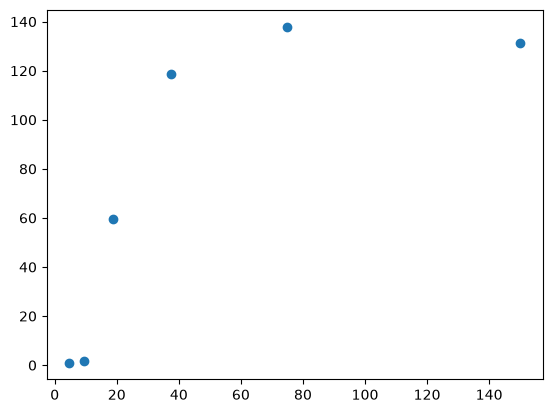

In [3]:
# Create independent variables (xdata) and dependent variable (ydata) for curve fitting

xdata = MM_df['Lactate (mM)']
ydata = MM_df['Rates']

# Inspect your data to make sure that it looks (soemthing like) a Michaelis-Menten plot

plt.plot(xdata, ydata, "o")

# Creating Functions

You should now be used to the idea of calling on functions from python libraries such as pandas, numpy, os, and matplotlib.  Hidden behind these functions that you call are blocks of code that perform particular tasks.  Many of the libraries that you use have hundreds or thousands of functions within them.  Commercialk software packages (excel for example) are similarly organised, but might have millions of functions.  Functions break up our code into smaller more easily understandable statements, and save us from having to re-write all the underlying code each time we want to do something - instead we just repeatedly call on the functions previously defined.

You might not see the code behind the functions you use, but they are there and there is nothing magic about them - you can create your own functions in python to do tasks that there aren't existing functions to do.  That is what we are going to do now.
In python, the following syntax is used to declare a function

```python
def function_name(independent_variable, parameter1, parameter2):
    **function body code to carry out the task**
    return value to return
```
Functions are defined using the `def` keyword, followed by the name of the function (since this is your functin, you define the name).  The function may have one or more than one independent variables, and one or more parameters, all stated in the parentheses following the function name.  Variables and parameters are  defined outside the function and passed to it.

A colon follows these parenthesis which causes the notebook to indent, helping you to see that the lines following define what the function is going to do.  Most functions return soime type of information, and jupyter notebooks recognises a line containing `return` as the end of the function.  This is probably all easier to see in practice

In [4]:
# Create a function for the equation you want to fit.  The function should accept as inputs 
# the independent variable (in this case xdata) and the parameters needed in the equation (in this case Km and Vmax)

def MM(subsconc, Vmax, Km):
    Vo = (Vmax * subsconc)/(Km + subsconc)
    return Vo

# Test the function to see that it outputs realistic results

MM(xdata, 100, 10)
    

0    93.750000
1    88.235294
2    78.947368
3    65.217391
4    48.400413
5    31.926481
Name: Lactate (mM), dtype: float64

# Using curve_fit

The syntax for the `curve_fit` function from `scipy.optimize` is

```python
popt, pcov = curve_fit(function, xdata, ydata)
```
|    Term    |   Signifies   |
|:---:       |:---:          |
|popt        |Pptimized parameters|
|curve_fit|The function from scipy.optimize|
|function|the function you choose that curve fit will use for fitting the data|
|xdata|a data array containing the independent variable|
|ydata|a data array containing the dependent variable|

You can learn much more about `curve_fit` by looking at the online documentation for [scipy.optimize.curve_fit](https://docs.scipy.org/doc/scipy-1.13.1/reference/generated/scipy.optimize.curve_fit.html)

Let's review the funtion `MM` that we defined above, to clearly distinguish the data, variables and parameters associated with `curve_fit` from those associated with `MM`

```python
def MM(SubConc,Vmax,Km):
    Vo = (Vmax * SubConc)/(Km + SubConc)
    return Vo
```
You need to pass three pieces of data to `MM` to predict the velocity for an enzyme-catalysed teraction: the substrate concentration, and values for Vmax and Km.

`scipy.optimize.curve_fit)_` can then fit the data to this `MM` function, to give a "line of best fit" in much the same way* as `linregress` fitted a straight line to our standard curves in a previous workshop.


*\*"in much the same way" here means "in a completely different way, but we don't need to worry about what either way is"*


In [6]:
# Use the function curve_fit to fit your data
popt, pcov = curve_fit(MM, xdata, ydata)

# Extracting the output fromcurve_fit

There are two outputs from curve_fit - popt and pcov.

1. popt = a list of the optimised parameters.  In this case the two parameters generated are Vmax and Km.  These are contained in a 2-dimensional array, so, since python starts counting at 0, popt[0] = Vmax and popt[1] = Km
2. pcov =  an array of the covariance (a measure of variability) for the estimated parameters.  Again, in this case there are two covarainces, so pcov[0] = covariance of Vmax and pcov[1] = covariance of Km

So we can extract the fitted values for Vmax and Km just by setting variables equal to them.  The covariance values can be used to extract standard deviations for each parameter.  IN our case we will calculate one standard deviation for each parameter.  We will use tow numpy functions (`aqrt` and `diag`) to calculate the standard deviations from the covariances.

In [7]:
#Extract the fit parameters from the output of curve_fit
Vmax = popt[0]
Km = popt[1]

#Extract covariances and calculate standard deviations for each parameter

stdev = np.sqrt(np.diag(pcov))

# Display the values for each parameter ± the stdev

VMaxlabel = (f'''Vmax for this reaction: 
{Vmax:.2f} ± {stdev[0]:.2f}''')
Kmlabel = (f'''Km for this reaction:
{Km:.2f} ± {stdev[1]:.2f}''')

print(VMaxlabel)
print(Kmlabel)


Vmax for this reaction: 
188.83 ± 51.57
Km for this reaction:
39.92 ± 27.76


# Plotting the data

At this point you want to compare your plotted experimental data with the data based on the parameters from curve_fit.  We'll do this in to stages.  First we'll use the MM function to calculate Y-values using your fit model.  Secondly we'll plot a line based on these Y-values on top of the experimental data

We will use `matplotlib.pyplot` (which we abbreviated in the opening cell of this notebook to `ply`) to create and annotate this plot.  Our firstplot will contain two sets of data:

1. The actual experimental data for initial velocity vs substrate concentration, from our pandas dataframe, MM_df
2. The fitted data calculated using the parameters generated by curve_fit

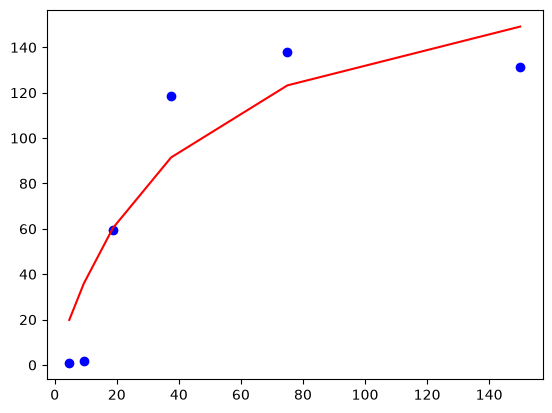

In [8]:
# using your fit model, calculated fitted vlaues for initial velocity (fit_y)

y_fit = MM(xdata, Vmax, Km)

#graph your original data and the fitted line

plt.plot(xdata, ydata, "bo", label = 'Experimental data')
plt.plot(xdata, y_fit, "r", label = 'Curve fit')

# Smoothing the line

You probably notices that the curve appears a bit lumpy and disjointed.  This is because the line is generated using only the original 11 values for substrate concentration form  our data-frame.  We can generate a much smoother line by using many more x-data points - 1000 seems like a good place to start.  To do this we use the numpy linspace function to generate a new list of 1000 equally spaced x-values covering the range of our substrate concentrations.  The we use curve_fit to generate y-values for each of these x-values.  Finally we repeat the plotting process above, to generate a plot containing experimental data and the calculated curve of best fit.  Finally we can titivate the plot to make sure it contains appropriate information and looks nice.

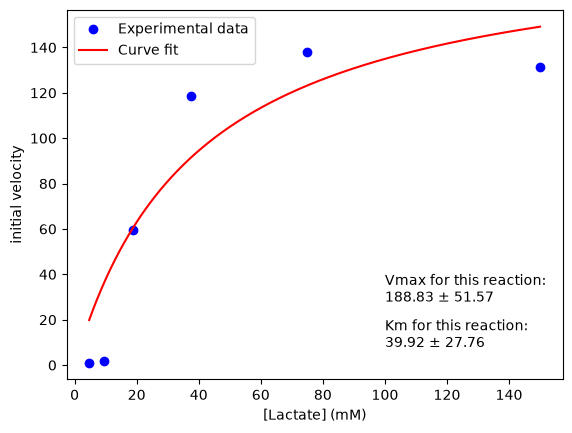

In [10]:
# Generate a large number of equally spaced x-data points

x_smooth = np.linspace(np.min(xdata), np.max(xdata), 1000)

# Generate y-data points for each x-data point
y_smooth = MM(x_smooth, Vmax, Km)

# plot experimental data (blue circles) and fitted line (red)
plt.plot(xdata, ydata, "bo", label = 'Experimental data')
plt.plot(x_smooth, y_smooth, "r", label = 'Curve fit')

# add a legend, x-axis and y-axis labels.  Annotate with the calculated parameters (Vmax and Km)
plt.legend()
plt.xlabel('[Lactate] (mM)')
plt.ylabel('initial velocity')
plt.annotate(VMaxlabel,xy = (100,28))
plt.annotate(Kmlabel,xy = (100,8))

# Save the plot as a JPEG file
plt.savefig('outputs/concentration_vs_absorbance.jpeg', format='jpeg')